thank you to chatgpt

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt

In [1]:
def b92_bit(ch1, ch2):
    """
    Map photon detector counts to Bob's bit according to B92 protocol.
    ch1: counts for |90°> detector (testing for 0)
    ch2: counts for |-45°> detector (testing for 1)
    Returns 0, 1, or None (inconclusive)
    """
    if ch1 > 0 and ch2 == 0:
        return 0
    elif ch2 > 0 and ch1 == 0:
        return 1
    else:
        return -1 # inconclusive, discard

In [3]:
def create_sifted_index_arrays(repeat_array, N_duplicate):
    """
    Creates an array of indices, where each value corresponds to the original index of a duplicate bit.
    E.g.
        Original string: 1 0 1 (indices 0,1,2)
        Repeat string (N=3): 111 000 111
        Received string: 1XX 0X1 XX0

        index array: [0, 1,1, 2] (corresponds to original bit)
    
    Inputs:
        repeat_array: received bit string
        N_duplicate: how many times each bit duplicated
    
    Outputs:
        sifted_array: array of information received
        index_array: corresponding indices
    """

    sifted_array = []
    index_array = []
    for i in range(len(repeat_array)):
        if repeat_array[i]!= -1:
            sifted_array.append(repeat_array[i])
            index_array.append(i//N_duplicate)
    
    return np.array(sifted_array), np.array(index_array)

def calculate_parity(sifted_array):
    """
    Calculates parity of a subarray.
    parity = sum(array) mod2

    Input: 
        - sifted_array : subarray to calculate parity of
    Output: 
        - p : parity
    """
    return np.sum(sifted_array)%2

def locate_error(A, B, offset=0):
    """ 
    Locates an error between Alice & Bob using a recursive binary search.
    Assumes parity(A) != parity(B), i.e., there is an error somewhere.

    Inputs:
        - A: Alice's sifted subarray
        - B: Bob's corresponding subarray
        - offset: starting index of this subarray in the original array

    Output:
        error_index: index in the original subarray where Bob has an error
    """
    if len(A) == 1:
        if A[0] != B[0]:
            return offset
        else:
            return None  # No error here (shouldn't happen if called correctly)
    
    mid = len(A) // 2
    # Check parity of the first half
    if calculate_parity(A[:mid]) != calculate_parity(B[:mid]):
        return locate_error(A[:mid], B[:mid], offset=offset)
    else:
        return locate_error(A[mid:], B[mid:], offset=offset + mid)




In [9]:
locate_error([1,0,1,1],[1,0,0,1])

2

In [17]:
import numpy as np

def cascade_correct(A, B, n_passes=4, block_size_init=8):
    """
    Basic (non-optimized) Cascade protocol.
    
    Inputs:
        A: Alice's bit array
        B: Bob's bit array (will be corrected)
        n_passes: number of Cascade passes
        block_size_init: initial block size
    
    Output:
        B_corrected
    """
    B = B.copy()
    N = len(A)

    def parity(arr):
        return np.sum(arr) % 2

    def binary_search_error(A_sub, B_sub, indices):
        """Locate a single error using recursive parity checks."""
        if len(indices) == 1:
            return indices[0]

        mid = len(indices) // 2
        left_idx = indices[:mid]
        right_idx = indices[mid:]

        if parity(A[left_idx]) != parity(B[left_idx]):
            return binary_search_error(A, B, left_idx)
        else:
            return binary_search_error(A, B, right_idx)

    for p in range(n_passes):
        # Increase block size each pass
        block_size = block_size_init * (2 ** p)

        # Shuffle indices (key part of Cascade)
        perm = np.random.permutation(N)
        
        # Process blocks
        for i in range(0, N, block_size):
            block = perm[i:i+block_size]

            if len(block) == 0:
                continue

            if parity(A[block]) != parity(B[block]):
                # Locate and fix error
                err_idx = binary_search_error(A, B, block)
                B[err_idx] = (B[err_idx]+1)%2  # flip bit

    return B

In [50]:
A = np.zeros(2048)
B = np.zeros(2048)

for i in range(len(B)):
    A[i] = np.random.randint(0,2)
    B[i] = A[i] + np.random.randint(0,51)//50

print(B[0:100])

[0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1.
 0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 1.
 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 2. 1. 1. 1. 0. 0. 0. 1. 1. 0.
 0. 0. 0. 0.]


In [52]:
def pick_npass_k1(length, error_rate):
    k1 = int(1 / error_rate)
    k1 = max(4, min(k1, length))
    return k1

In [56]:
k = pick_npass_k1(2048, .02)
B_corr = cascade_correct(A,B,n_passes=3, block_size_init=k)
print(A[0:100] - B_corr[0:100])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


In [ ]:
import numpy as np

# -------------------------------
# Step 1: Build sifted arrays + index map
# -------------------------------
def create_sifted_index_arrays(repeat_array, N_duplicate):
    sifted_array = []
    index_array = []

    for i in range(len(repeat_array)):
        if repeat_array[i] != -1:
            sifted_array.append(repeat_array[i])
            index_array.append(i // N_duplicate)

    return np.array(sifted_array), np.array(index_array)


# -------------------------------
# Step 2: Basic Cascade
# -------------------------------
def cascade_correct(A, B, n_passes=4):
    B = B.copy()
    N = len(A)

    def parity(x):
        return np.sum(x) % 2

    def binary_search_error(indices):
        if len(indices) == 1:
            return indices[0]

        mid = len(indices) // 2
        left = indices[:mid]
        right = indices[mid:]

        if parity(A[left]) != parity(B[left]):
            return binary_search_error(left)
        else:
            return binary_search_error(right)

    # Estimate error rate
    q = np.mean(A != B)
    k1 = max(8, int(1 / q)) if q > 0 else N

    for p in range(n_passes):
        block_size = k1 * (2 ** p)

        perm = np.random.permutation(N)

        for i in range(0, N, block_size):
            block = perm[i:i + block_size]
            if len(block) == 0:
                continue

            if parity(A[block]) != parity(B[block]):
                err_idx = binary_search_error(block)
                B[err_idx] ^= 1  # flip bit

    return B, q


# -------------------------------
# Step 3: Reconstruct original bitstring
# -------------------------------
def reconstruct_original(B_sifted, index_array, original_length):
    counts = [[] for _ in range(original_length)]

    for bit, idx in zip(B_sifted, index_array):
        counts[idx].append(bit)

    reconstructed = np.zeros(original_length, dtype=int)

    for i in range(original_length):
        if len(counts[i]) == 0:
            reconstructed[i] = 0  # default if all invalid
        else:
            reconstructed[i] = int(np.round(np.mean(counts[i])))

    return reconstructed


# -------------------------------
# Step 4: Full pipeline
# -------------------------------
def full_qkd_pipeline(A_original, B_received, N_duplicate):
    """
    Inputs:
        A_original : Alice's original bitstring
        B_received : Bob's received duplicated string (with -1 for invalid)
        N_duplicate : duplication factor

    Outputs:
        B_final : reconstructed original bitstring for Bob
        q_initial : initial sifted error rate
        final_error_rate : error vs original
    """

    # Build Alice's duplicated version
    A_repeated = np.repeat(A_original, N_duplicate)

    # Sift + index map
    A_sifted, index_array = create_sifted_index_arrays(A_repeated, N_duplicate)
    B_sifted, _ = create_sifted_index_arrays(B_received, N_duplicate)

    # Cascade correction
    B_corrected, q_initial = cascade_correct(A_sifted, B_sifted)

    # Reconstruct original bitstring
    B_final = reconstruct_original(
        B_corrected,
        index_array,
        len(A_original)
    )

    # Final error
    final_error_rate = np.mean(B_final != A_original)

    return B_final, q_initial, final_error_rate

In [70]:
import numpy as np

# -------------------------------
# Load CSVs
# -------------------------------
def load_data(init_file, ch1_file, ch2_file):
    init = np.loadtxt(init_file, delimiter=',', dtype=int)
    ch1 = np.loadtxt(ch1_file, delimiter=',')
    ch2 = np.loadtxt(ch2_file, delimiter=',')
    return init, ch1, ch2


# -------------------------------
# Convert counts → bitstring
# -------------------------------
def counts_to_bits(ch1, ch2):
    """
    Returns:
        B_received: array with {0,1,-1}
    """
    B = np.full(len(ch1), -1, dtype=int)

    for i in range(len(ch1)):
        if ch1[i] > ch2[i]:
            B[i] = 1
        elif ch2[i] > ch1[i]:
            B[i] = 0
        else:
            B[i] = -1  # tie → discard

    return B


# -------------------------------
# Sifting + index map
# -------------------------------
def create_sifted_index_arrays(A_repeat, B_received, N_duplicate):
    A_sifted = []
    B_sifted = []
    index_array = []

    for i in range(len(B_received)):
        if B_received[i] != -1:
            A_sifted.append(A_repeat[i])
            B_sifted.append(B_received[i])
            index_array.append(i // N_duplicate)

    return np.array(A_sifted), np.array(B_sifted), np.array(index_array)


# -------------------------------
# Cascade
# -------------------------------
def cascade_correct(A, B, n_passes=4):
    B = B.copy()
    N = len(A)

    def parity(x):
        return np.sum(x) % 2

    def binary_search(indices):
        if len(indices) == 1:
            return indices[0]

        mid = len(indices) // 2
        left = indices[:mid]
        right = indices[mid:]

        if parity(A[left]) != parity(B[left]):
            return binary_search(left)
        else:
            return binary_search(right)

    q = np.mean(A != B)
    k1 = max(8, int(1 / q)) if q > 0 else N

    for p in range(n_passes):
        block_size = k1 * (2 ** p)
        perm = np.random.permutation(N)

        for i in range(0, N, block_size):
            block = perm[i:i + block_size]
            if len(block) == 0:
                continue

            if parity(A[block]) != parity(B[block]):
                err_idx = binary_search(block)
                B[err_idx] ^= 1

    return B, q


# -------------------------------
# Reconstruct original
# -------------------------------
def reconstruct_original(B_sifted, index_array, original_length):
    buckets = [[] for _ in range(original_length)]

    for bit, idx in zip(B_sifted, index_array):
        buckets[idx].append(bit)

    result = np.zeros(original_length, dtype=int)

    for i in range(original_length):
        if len(buckets[i]) == 0:
            result[i] = 0
        else:
            result[i] = int(np.round(np.mean(buckets[i])))

    return result


# -------------------------------
# Full pipeline
# -------------------------------
def run_pipeline(init_file, ch1_file, ch2_file, N_duplicate=16):

    # Load
    A_repeat, ch1, ch2 = load_data(init_file, ch1_file, ch2_file)

    # Infer original length
    N_original = len(A_repeat) // N_duplicate
    A_original = A_repeat[::N_duplicate]

    # Build Bob's received bits
    B_received = counts_to_bits(ch1, ch2)

    # Sift
    A_sifted, B_sifted, index_array = create_sifted_index_arrays(
        A_repeat, B_received, N_duplicate
    )

    # Cascade
    B_corrected, q_initial = cascade_correct(A_sifted, B_sifted, n_passes=12)

    # Reconstruct
    B_final = reconstruct_original(
        B_corrected,
        index_array,
        N_original
    )

    # Final error
    final_error = np.mean(B_final != A_original)

    print("Initial sifted error rate:", q_initial)
    print("Final logical error rate:", final_error)

    return B_final

In [71]:
final_string = run_pipeline("initial_cyrus_bits.csv", "ch1_cyrus.csv", "ch2_cyrus.csv")

Initial sifted error rate: 0.012631876047467242
Final logical error rate: 0.002491455078125


In [63]:
from QCrypt_Methods import *


In [68]:
string = ""
for x in final_string:
    string+=f"{x}"

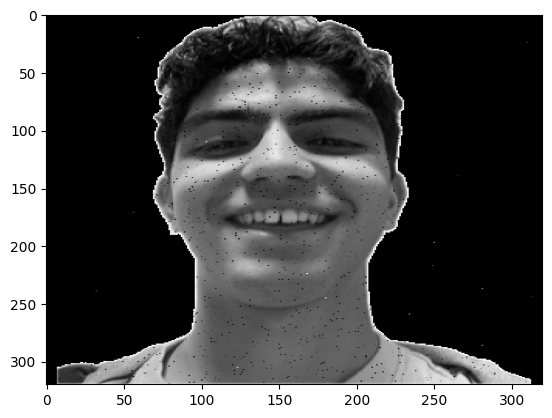

In [69]:
fmat = bitstring_to_int_matrix(string)
plt.imshow(fmat/256, cmap=plt.get_cmap("gray"), aspect='auto')
plt.show()

#plt.imshow(reconstucted_matrix/256 - fmat/256 , cmap=plt.get_cmap("gray"), aspect='auto')
#plt.show()